## Simulate the model under constant gain learning

In [1]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [13]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
sigma_x = 0.01 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
constant_gain = 0.001  # constant gain parameter for learning

## Univariate case

In [14]:
def univariate_CGL(T, sigma_x, sigma, kappa, w, seed=None, constant_gain=0.01):
    if seed is not None:
        np.random.seed(seed)

    # Initialization
    x = np.random.normal(0, sigma_x, T) # observable variable
    r = np.zeros(T) # actual gross returns
    beta = np.zeros(T) # coefficient for the observable variable
    M = np.zeros(T)
    #Starting values
    beta[0] = np.random.normal(0, 0.001) #small perturbation around REE
    beta[1] = np.random.normal(0, 0.001)
    M[0] = sigma_x ** 2 # initial variance of the observable variable 
    r[1] = np.random.normal(0, 0.0001) 
    for t in range(2, T):
        # update M
        M[t-1] = M[t-2] + (x[t-2]**2 - M[t-2]) * constant_gain
        # update beta using RLS
        beta[t] = beta[t-1] + constant_gain * ( M[t-1]) ** -1 * (x[t-2] * r[t-1] - x[t-2]**2 * beta[t-1])
        # compute expected returns
        r[t] = np.log(1 - kappa * np.exp(w * np.tanh(beta[t-1] * x[t-1] / w))) - np.log(1 - kappa * np.exp(w * np.tanh(beta[t] * x[t] / w))) + np.random.normal(0, sigma)
    return beta.reshape(-1, 1), r.reshape(-1, 1)


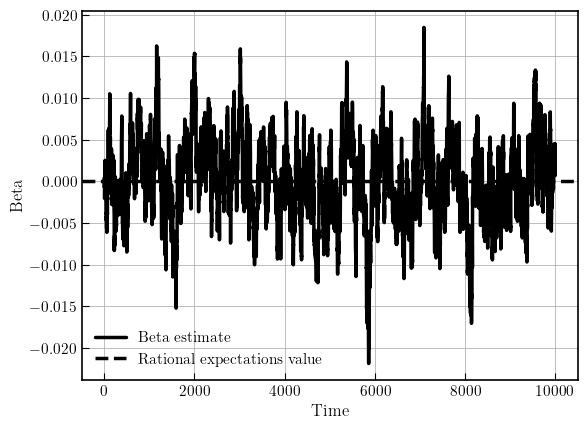

In [15]:
beta, r = univariate_CGL(T=10000, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, constant_gain=constant_gain, seed=42)

#visualize beta coefficient over time
fig, ax = plt.subplots()
ax.plot(beta, label='Beta estimate')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

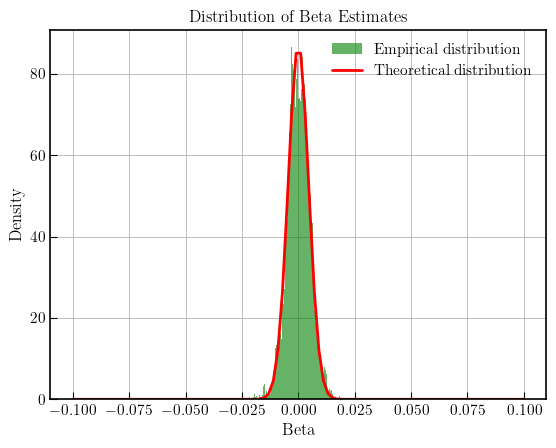

In [17]:
#check actual distribution vs theoretical distribution of beta
def theoretical_var(constant_gain, sigma_x, s_d, kappa):
    return constant_gain * s_d**2 * (1.0 - kappa) / (2.0 * sigma_x**2)

theoretical_variance = theoretical_var(constant_gain, sigma_x, sigma, kappa)
empirical_variance = np.var(beta)

fig, ax = plt.subplots()
ax.hist(beta, bins=100, density=True, alpha=0.6, color='g', label='Empirical distribution')
x = np.linspace(-0.1, 0.1, 100)
theoretical_pdf = (1 / np.sqrt(2 * np.pi * theoretical_variance)) * np.exp(- (x ** 2) / (2 * theoretical_variance))
ax.plot(x, theoretical_pdf, 'r-', lw=2, label='Theoretical distribution')
ax.set_title('Distribution of Beta Estimates')
ax.set_xlabel('Beta')
ax.set_ylabel('Density')
ax.legend()
plt.show()



In [5]:
#montecarlo simulation to get distribution of beta estimates
T_mc = 5000
N_paths = 200
burn = 1000
thin = 10

beta_draws = []
for n in range(N_paths):
    beta_path, r_path = univariate_CGL(
        T=T_mc, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, constant_gain=constant_gain,
        seed = n
    )
    # collect post-burn-in, thinned draws
    beta_draws.append(beta_path[burn::thin, 0])

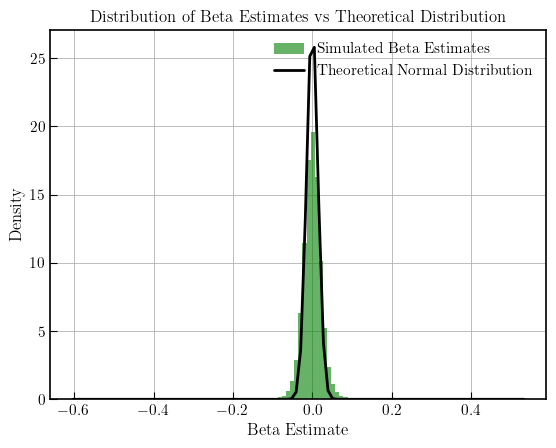

In [6]:
# visualize distribution of beta estimates vs theoretical normal distribution
betas = np.array(beta_draws)
betas = betas.reshape(-1, 1, 1)

def theoretical_beta_var(constant_gain, sigma, sigma_x, kappa):
    return constant_gain * sigma**2 * (1.0 - kappa) / (2.0 * sigma_x**2)

theoretical_var = theoretical_beta_var(constant_gain, sigma, sigma_x, kappa)
theoretical_std = np.sqrt(theoretical_var)  

fig, ax = plt.subplots()
ax.hist(betas[:, 0, 0], bins=100, density=True, alpha=0.6, color='g', label='Simulated Beta Estimates')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / (theoretical_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x) / theoretical_std) ** 2)
ax.plot(x, p, 'k', linewidth=2, label='Theoretical Normal Distribution')
ax.set_title('Distribution of Beta Estimates vs Theoretical Distribution')
ax.set_xlabel('Beta Estimate')
ax.set_ylabel('Density')
ax.legend()
plt.show()


## Multivariate case (2 is enough)

In [7]:
def multivariate_CGL(T, K, sigma_x, sigma, kappa, w, seed = None, constant_gain=0.01):
    rng = np.random.default_rng(seed)
    
    x = rng.normal(0, sigma_x, (T, K)) # observable variables
    beta = np.zeros((T, K, 1)) # coefficients for the observable variables
    M = np.zeros((T, K, K))
    r = np.zeros(T) # actual gross returns

    #Starting values
    beta[0, :, 0] = np.random.normal(0, 0.001, K) #small perturbation around REE
    beta[1, :, 0] = np.random.normal(0, 0.001, K)
    M[0, :, :] = np.eye(K) * sigma_x ** 2 # initial variance of the observable variables 
    r[1] = np.random.normal(0, 0.0001)

    for t in range(2, T):
        # update M
        M[t-1, :, :] = M[t-2, :, :] + (np.outer(x[t-2, :], x[t-2, :]) - M[t-2, :, :]) * constant_gain
        # update beta using RLS
        beta[t, :, 0] = beta[t-1, :, 0] + constant_gain * np.linalg.inv( M[t-1, :, :]) @ (x[t-2, :].reshape(-1, 1) * r[t-1] - (x[t-2, :].reshape(-1, 1) @ x[t-2, :].reshape(1, -1)) @ beta[t-1, :, 0].reshape(-1, 1)).flatten()
        # compute expected returns
        r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)
    return beta, r

In [8]:
def multivariate_CGL_offline(T, K, sigma_x, sigma, kappa, w, rolling_window_size = 30):
    
    #assert that rolling_window_size < T otherwise offline estimation is not possible
    assert rolling_window_size < T, "rolling_window_size must be less than T"

    x = np.random.normal(0, sigma_x, (T, K)) # observable variables
    beta_offline = np.zeros((T, K, 1))
    r_offline = np.zeros(T)

    #Starting values
    r_offline[1:rolling_window_size+1] = np.random.normal(0, 0.0001, rolling_window_size)


    for t in range(rolling_window_size+1, T):
        #generate x_current, up and including t-2
        x_current = x[t-rolling_window_size:t-1,:]
        r_offline_current = r_offline[t-rolling_window_size+1:t]
        beta_offline[t] = np.linalg.pinv(x_current.T @ x_current) @ x_current.T @ r_offline_current.reshape(-1,1)
        r_offline[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)
    return beta_offline, r_offline

In [9]:
beta, r = multivariate_CGL(T=1000, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_13293/3558346556.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


In [10]:
beta_offline, r_offline = multivariate_CGL_offline(T=1000, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, rolling_window_size=150)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_13293/776514298.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r_offline[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta_offline[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


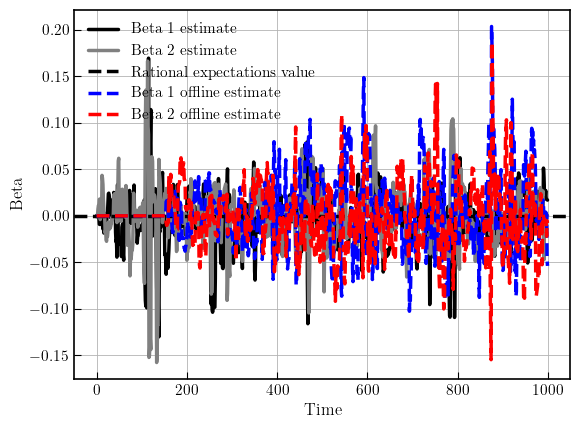

In [11]:
#visualzie the two betas over time
fig, ax = plt.subplots()
ax.plot(beta[:, 0, 0], label='Beta 1 estimate')
ax.plot(beta[:, 1, 0], label='Beta 2 estimate', color = 'gray')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
#add offline estimates
ax.plot(beta_offline[:, 0, 0], label='Beta 1 offline estimate', linestyle='dashed', color = 'blue')
ax.plot(beta_offline[:, 1, 0], label='Beta 2 offline estimate', linestyle='dashed', color = 'red')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

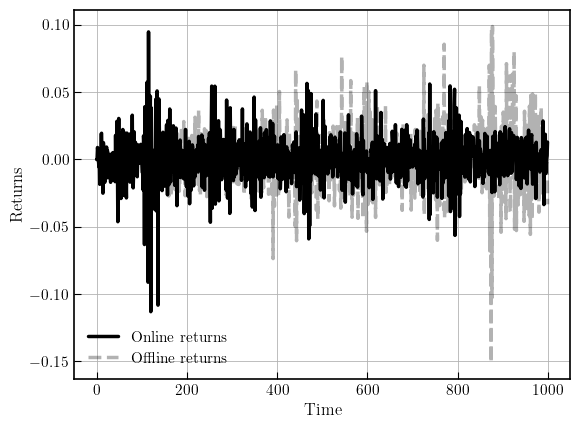

In [12]:
#visualize online vs offline returns
fig, ax = plt.subplots()
ax.plot(r, label='Online returns')
ax.plot(r_offline, label='Offline returns', linestyle='dashed', alpha = 0.3)
ax.set_ylabel('Returns')
ax.set_xlabel('Time')
ax.legend()
plt.show()

In [13]:
## Check with multiple stochastic seeds to ensure robustness
num_simulations = 100
all_betas = []
for sim in range(num_simulations):
    np.random.seed(sim)
    beta, r = multivariate_CGL(T=1000, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w)
    all_betas.append(beta)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_13293/3558346556.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


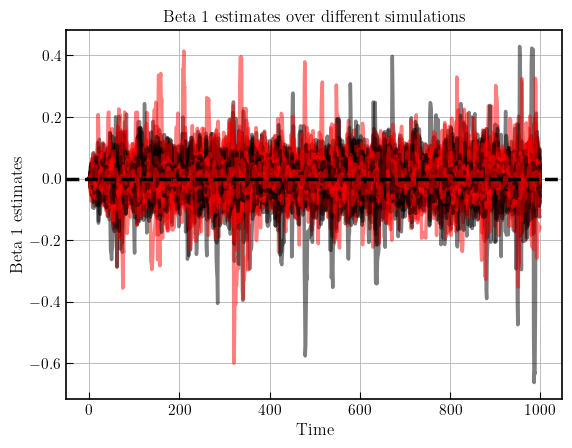

In [14]:
#visualization of coefficients over seeds
fig, ax = plt.subplots()
for sim in range(num_simulations):
    ax.plot(all_betas[sim][:, 0, 0], alpha=0.5, label = 'beta_1')
    ax.plot(all_betas[sim][:, 1, 0], alpha=0.5, color = 'red', label = 'beta_2')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta 1 estimates')
ax.set_xlabel('Time')
ax.set_title('Beta 1 estimates over different simulations')
plt.show()


## Monte Carlo check: simulated vs theoretical distribution of $\beta_t$

For the univariate case ($K=1$), the theory predicts (for small constant gain) that the stationary distribution of the learning coefficient is approximately

$$
\beta_t \approx \mathcal N\left(0,\; \gamma\,\frac{\sigma^2(1-\kappa)}{2\sigma_x^2}\right),
$$

where in this notebook `sigma` is the standard deviation of $\log(\varepsilon^d_t)$ and `constant_gain` is the gain parameter.


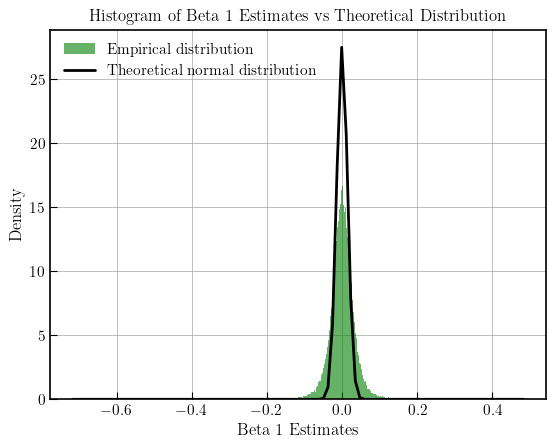

In [17]:

import matplotlib.pyplot as plt
from math import sqrt, pi

def theoretical_beta_var(constant_gain, sigma, sigma_x, kappa):
    return constant_gain * sigma**2 * (1.0 - kappa) / (2.0 * sigma_x**2)

#stack the corrisponding beta_1 estimates from all simulations
betas0 = np.vstack([all_betas[sim][:, 0, 0].reshape(-1, 1, 1) for sim in range(num_simulations)])
betas1 = np.vstack([all_betas[sim][:, 1, 0].reshape(-1, 1, 1) for sim in range(num_simulations)])
betas = np.vstack((betas0, betas1))


# plot the histogram of beta estimates
fig, ax = plt.subplots()
ax.hist(np.array(betas[:, 0, 0]), bins=1000, density=True, alpha=0.6, color='g', label='Empirical distribution')
# plot the theoretical normal distribution
mu = 0
theoretical_var = theoretical_beta_var(constant_gain, sigma, sigma_x, kappa)
theoretical_std = sqrt(theoretical_var)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / (theoretical_std * sqrt(2 * pi))) * np.exp(-0.5 * ((x - mu) / theoretical_std) ** 2)
ax.plot(x, p, 'k', linewidth=2, label='Theoretical normal distribution')
ax.set_title('Histogram of Beta 1 Estimates vs Theoretical Distribution')
ax.set_xlabel('Beta 1 Estimates')
ax.set_ylabel('Density')
ax.legend()
plt.show()
